<a href="https://colab.research.google.com/github/olakiitanEsther/PythonCourseWorks/blob/main/IDS_Analogy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = 100

# Generate random Temperature values between 36°C and 39°C
temperature = np.random.uniform(36, 39, n_samples)

# Generate random Sweating values: 0 = No, 1 = Yes
sweating = np.random.choice([0, 1], size=n_samples)

# Rule to label Intruder: High temperature (>37.5) AND sweating = 1 (likely intruder), else 0
intruder = ((temperature > 37.5) & (sweating == 1)).astype(int)

# Create DataFrame
data = pd.DataFrame({
    "Temperature": temperature,
    "Sweating": sweating,
    "Intruder": intruder
})

# Print first 10 rows to see the table
print(data.head(10))

# Optionally, save to CSV for later use
data.to_csv("intruder_dataset.csv", index=False)

   Temperature  Sweating  Intruder
0    37.123620         0         0
1    38.852143         1         1
2    38.195982         0         0
3    37.795975         0         0
4    36.468056         1         0
5    36.467984         0         0
6    36.174251         1         0
7    38.598528         1         1
8    37.803345         1         1
9    38.124218         0         0


Sample data:
   Temperature  Sweating  Intruder
0    37.123620         0         0
1    38.852143         1         1
2    38.195982         0         0
3    37.795975         0         0
4    36.468056         1         0
5    36.467984         0         0
6    36.174251         1         0
7    38.598528         1         1
8    37.803345         1         1
9    38.124218         0         0

Accuracy: 1.0

Confusion Matrix:
 [[14  0]
 [ 0  6]]


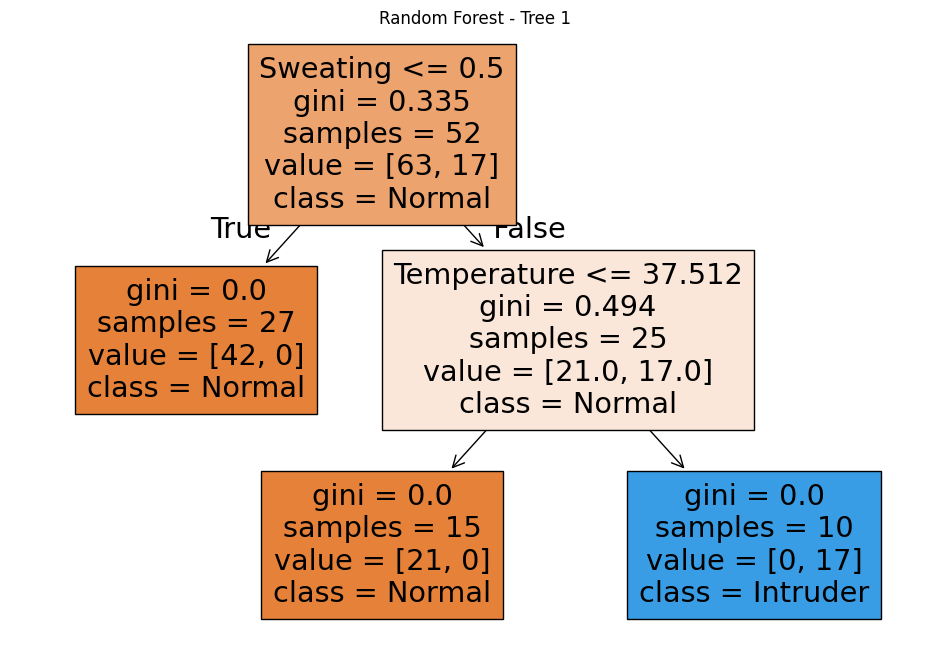


Rules of Tree 1:
 |--- Sweating <= 0.50
|   |--- class: 0.0
|--- Sweating >  0.50
|   |--- Temperature <= 37.51
|   |   |--- class: 0.0
|   |--- Temperature >  37.51
|   |   |--- class: 1.0



In [ ]:
# 1️⃣ Import libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt

# 2️⃣ Generate dataset
np.random.seed(42)
n_samples = 100

temperature = np.random.uniform(36, 39, n_samples)  # Temperature in °C
sweating = np.random.choice([0, 1], size=n_samples)  # 0 = No, 1 = Yes
intruder = ((temperature > 37.5) & (sweating == 1)).astype(int)  # Label

data = pd.DataFrame({
    "Temperature": temperature,
    "Sweating": sweating,
    "Intruder": intruder
})

print("Sample data:")
print(data.head(10))

# 3️⃣ Split into features and target
X = data[["Temperature", "Sweating"]]
y = data["Intruder"]

# 4️⃣ Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5️⃣ Create and train Random Forest
rf_model = RandomForestClassifier(n_estimators=5, random_state=42)  # 5 trees for visualization
rf_model.fit(X_train, y_train)

# 6️⃣ Predict on test set
y_pred = rf_model.predict(X_test)

# 7️⃣ Evaluate model
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 8️⃣ Visualize one of the trees
plt.figure(figsize=(12,8))
plot_tree(rf_model.estimators_[0], feature_names=X.columns, class_names=["Normal","Intruder"], filled=True)
plt.title("Random Forest - Tree 1")
plt.show()

# Optional: show textual tree
tree_rules = export_text(rf_model.estimators_[0], feature_names=list(X.columns))
print("\nRules of Tree 1:\n", tree_rules)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# Step 1: Generate dataset
# -----------------------------
np.random.seed(42)
n_samples = 100
temperature = np.random.uniform(36, 39, n_samples)
sweating = np.random.choice([0, 1], size=n_samples)
intruder = ((temperature > 37.5) & (sweating == 1)).astype(int)

data = pd.DataFrame({
    "Temperature": temperature,
    "Sweating": sweating,
    "Intruder": intruder
})

# -----------------------------
# Step 2: Train Random Forest
# -----------------------------
X = data[["Temperature", "Sweating"]]
y = data["Intruder"]

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# -----------------------------
# Step 3: Input function for interactive checking
# -----------------------------
def check_intruder():
    while True:
        try:
            print("\n--- Intruder Check ---")
            temp = float(input("Enter Temperature (°C) or 'q' to quit: "))
            sweat = int(input("Sweating? 0 = No, 1 = Yes: "))
            prediction = rf_model.predict([[temp, sweat]])
            if prediction[0] == 1:
                print("⚠️ Intruder detected!")
            else:
                print("✅ Not an intruder")
        except ValueError:
            print("Invalid input. Type numbers only or 'q' to quit.")
            break

# -----------------------------
# Step 4: Run the interactive checker
# -----------------------------
check_intruder()quit


SyntaxError: invalid syntax (ipython-input-2346095270.py, line 50)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# Step 1: Generate dataset
# -----------------------------
np.random.seed(42)
n_samples = 100
temperature = np.random.uniform(36, 39, n_samples)
sweating = np.random.choice([0, 1], size=n_samples)
intruder = ((temperature > 37.5) & (sweating == 1)).astype(int)

data = pd.DataFrame({
    "Temperature": temperature,
    "Sweating": sweating,
    "Intruder": intruder
})

# -----------------------------
# Step 2: Train Random Forest
# -----------------------------
X = data[["Temperature", "Sweating"]]
y = data["Intruder"]

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# -----------------------------
# Step 3: Input function for interactive checking
# -----------------------------
def check_intruder():
    while True:
        try:
            print("\n--- Intruder Check ---")
            temp = float(input("Enter Temperature (°C) or 'q' to quit: "))
            sweat = int(input("Sweating? 0 = No, 1 = Yes: "))
            prediction = rf_model.predict([[temp, sweat]])
            if prediction[0] == 1:
                print("⚠️ Intruder detected!")
            else:
                print("✅ Not an intruder")
        except ValueError:
            print("Invalid input. Type numbers only or 'q' to quit.")
            break

# -----------------------------
# Step 4: Run the interactive checker
# -----------------------------
check_intruder()


--- Intruder Check ---
Enter Temperature (°C) or 'q' to quit: 37.98
Sweating? 0 = No, 1 = Yes: Yes
Invalid input. Type numbers only or 'q' to quit.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# Step 1: Generate dataset
# -----------------------------
np.random.seed(42)
n_samples = 100
temperature = np.random.uniform(36, 39, n_samples)
sweating = np.random.choice([0, 1], size=n_samples)
intruder = ((temperature > 37.5) & (sweating == 1)).astype(int)

data = pd.DataFrame({
    "Temperature": temperature,
    "Sweating": sweating,
    "Intruder": intruder
})

# -----------------------------
# Step 2: Train Random Forest
# -----------------------------
X = data[["Temperature", "Sweating"]]
y = data["Intruder"]

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# -----------------------------
# Step 3: Input function for interactive checking
# -----------------------------
def check_intruder():
    while True:
        try:
            print("\n--- Intruder Check ---")
            temp = float(input("Enter Temperature (°C) or 'q' to quit: "))
            sweat = int(input("Sweating? 0 = No, 1 = Yes: "))
            prediction = rf_model.predict([[temp, sweat]])
            if prediction[0] == 1:
                print("⚠️ Intruder detected!")
            else:
                print("✅ Not an intruder")
        except ValueError:
            print("Invalid input. Type numbers only or 'q' to quit.")
            break

# -----------------------------
# Step 4: Run the interactive checker
# -----------------------------
check_intruder()


--- Intruder Check ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


✅ Not an intruder

--- Intruder Check ---
